In [1]:

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Any, Tuple, List

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Deep Learning (Keras MLP)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, models

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Data config
DATA_PATH = "../results/outputs/scaled.csv"
TARGET_COL = "Status"
TEST_SIZE = 0.2


In [2]:
data = pd.read_csv(DATA_PATH)
X = data.drop(columns=[TARGET_COL])
y = data[TARGET_COL]

print("✅ Dataset loaded")
print("Shape:", X.shape)
print("Target distribution:\n", y.value_counts(), "\n")

classes = sorted(y.unique())
num_classes = len(classes)
is_binary = (num_classes == 2)
print(f"Detected {num_classes} class(es): {classes}")

✅ Dataset loaded
Shape: (15000, 20)
Target distribution:
 Status
0    5000
1    5000
2    5000
Name: count, dtype: int64 

Detected 3 class(es): [np.int64(0), np.int64(1), np.int64(2)]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print("Train/Test shapes:", X_train.shape, y_train.shape, "|", X_test.shape, y_test.shape)

Train/Test shapes: (12000, 20) (12000,) | (3000, 20) (3000,)


In [4]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [5]:
pipe_lr = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
])
param_grid_lr = {"clf__penalty": ["l1", "l2"], "clf__C": [0.01, 0.1, 1.0, 10.0]}

pipe_svm = Pipeline([
    ("pre", preprocessor),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE))
])
param_grid_svm = {"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", 0.01, 0.1, 1]}

pipe_dt = Pipeline([
    ("pre", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
])
param_grid_dt = {
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4]
}

models_and_grids = [
    ("LogisticRegression", pipe_lr, param_grid_lr),
    ("SVM", pipe_svm, param_grid_svm),
    ("DecisionTree", pipe_dt, param_grid_dt)
]

# For multiclass, use weighted metrics to reflect all classes fairly
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_weighted"
}

In [6]:
best_estimators: Dict[str, Any] = {}
cv_rows: List[Dict[str, Any]] = []

for name, pipe, grid in models_and_grids:
    print(f"\n🔎 GridSearchCV: {name}")
    gs = GridSearchCV(
        pipe, grid, scoring=scoring, refit="f1",
        cv=cv, n_jobs=-1, verbose=1, return_train_score=False
    )
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_
    idx = gs.best_index_
    row = {
        "Model": name,
        "Best Params": gs.cv_results_["params"][idx],
        "CV Accuracy": gs.cv_results_["mean_test_accuracy"][idx],
        "CV F1": gs.cv_results_["mean_test_f1"][idx],
    }
    print("✅ Best CV summary:", row)
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows)
print("\n📊 Cross-Validation Summary:")
print(cv_results_df)


🔎 GridSearchCV: LogisticRegression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best CV summary: {'Model': 'LogisticRegression', 'Best Params': {'clf__C': 0.1, 'clf__penalty': 'l2'}, 'CV Accuracy': np.float64(0.6636666666666666), 'CV F1': np.float64(0.6617258930130625)}

🔎 GridSearchCV: SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits
✅ Best CV summary: {'Model': 'SVM', 'Best Params': {'clf__C': 10, 'clf__gamma': 0.1}, 'CV Accuracy': np.float64(0.96), 'CV F1': np.float64(0.9599627880162673)}

🔎 GridSearchCV: DecisionTree
Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best CV summary: {'Model': 'DecisionTree', 'Best Params': {'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}, 'CV Accuracy': np.float64(0.96675), 'CV F1': np.float64(0.9667598688250238)}

📊 Cross-Validation Summary:
                Model                                        Best Params  \
0  LogisticRegression              {'clf__C': 0.1, 'cl

In [7]:
def compute_auc(y_true, y_prob):
    """Handle binary & multiclass AUC."""
    if y_prob is None:
        return np.nan
    if is_binary:
        return roc_auc_score(y_true, y_prob[:, 1])
    else:
        y_bin = label_binarize(y_true, classes=classes)
        return roc_auc_score(y_bin, y_prob, average="weighted", multi_class="ovr")

def evaluate_model(name: str, est, X_te, y_te):
    """Compute metrics + plot Confusion Matrix & ROC curve if possible."""
    y_pred = est.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_te, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_te, y_pred, average="weighted", zero_division=0)
    y_prob = est.predict_proba(X_te) if hasattr(est, "predict_proba") else None
    auc = compute_auc(y_te, y_prob)

    print(f"\n=== {name} (Test) ===")
    print(f"Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    print(classification_report(y_te, y_pred, digits=3))

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC curve (sklearn helper handles multiclass OVR plotting for some estimators)
    if y_prob is not None:
        try:
            RocCurveDisplay.from_predictions(
                label_binarize(y_te, classes=classes) if not is_binary else y_te,
                y_prob if not is_binary else y_prob[:,1],
                name=f"{name} (OVR)" if not is_binary else f"{name}"
            )
            plt.title(f"ROC Curve - {name}")
            plt.show()
        except Exception:
            pass

    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc}



=== LogisticRegression (Test) ===
Accuracy=0.6583 | Precision=0.6616 | Recall=0.6583 | F1=0.6551 | AUC=0.8206
              precision    recall  f1-score   support

           0      0.615     0.737     0.671      1000
           1      0.701     0.717     0.709      1000
           2      0.669     0.521     0.586      1000

    accuracy                          0.658      3000
   macro avg      0.662     0.658     0.655      3000
weighted avg      0.662     0.658     0.655      3000



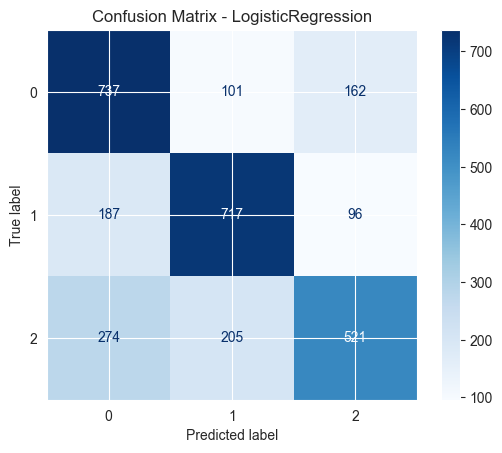


=== SVM (Test) ===
Accuracy=0.9637 | Precision=0.9637 | Recall=0.9637 | F1=0.9637 | AUC=0.9926
              precision    recall  f1-score   support

           0      0.946     0.949     0.948      1000
           1      0.985     0.986     0.986      1000
           2      0.960     0.956     0.958      1000

    accuracy                          0.964      3000
   macro avg      0.964     0.964     0.964      3000
weighted avg      0.964     0.964     0.964      3000



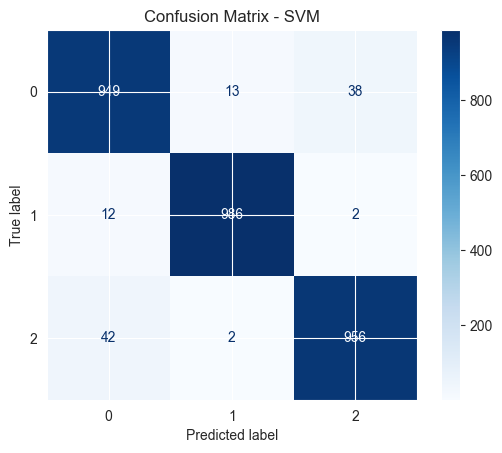


=== DecisionTree (Test) ===
Accuracy=0.9713 | Precision=0.9713 | Recall=0.9713 | F1=0.9713 | AUC=0.9785
              precision    recall  f1-score   support

           0      0.969     0.965     0.967      1000
           1      0.976     0.985     0.981      1000
           2      0.969     0.964     0.966      1000

    accuracy                          0.971      3000
   macro avg      0.971     0.971     0.971      3000
weighted avg      0.971     0.971     0.971      3000



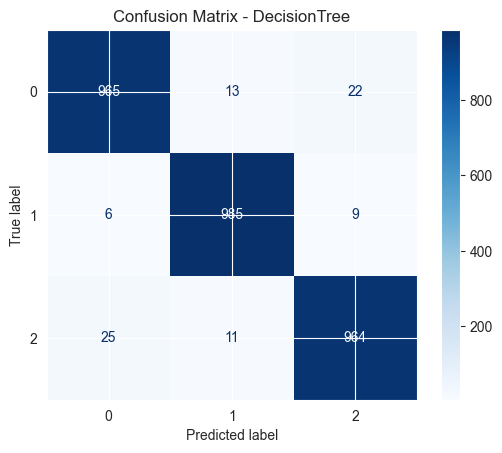


📈 Test Results Summary:
                Model  Accuracy  Precision    Recall        F1       AUC
0  LogisticRegression  0.658333   0.661626  0.658333  0.655060  0.820581
1                 SVM  0.963667   0.963672  0.963667  0.963667  0.992614
2        DecisionTree  0.971333   0.971311  0.971333  0.971312  0.978494


In [8]:
test_rows = []
for name, est in best_estimators.items():
    res = evaluate_model(name, est, X_test, y_test)
    test_rows.append(res)

test_results_df = pd.DataFrame(test_rows)
print("\n📈 Test Results Summary:")
print(test_results_df)

In [9]:
print("\n🔬 PCA & Logistic Regression comparison...")

pipe_lr_pca = Pipeline([
    ("pre", preprocessor),
    ("pca", PCA(n_components=10)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
])
param_grid_lr_pca = {
    "pca__n_components": [5, 10, 15],
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.1, 1.0, 10.0]
}
gs_lr_pca = GridSearchCV(
    pipe_lr_pca, param_grid_lr_pca,
    scoring="f1_weighted", cv=cv, n_jobs=-1, verbose=1
)
gs_lr_pca.fit(X_train, y_train)
lr_pca_best = gs_lr_pca.best_estimator_

def eval_short(name, est):
    y_pred = est.predict(X_test)
    y_prob = est.predict_proba(X_test)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred, average="weighted"),
        "AUC": compute_auc(y_test, y_prob)
    }

lr_compare_df = pd.DataFrame([
    eval_short("LR_No_PCA", best_estimators["LogisticRegression"]),
    eval_short("LR_With_PCA", lr_pca_best)
])
print("\n📘 Logistic Regression: PCA Comparison")
print(lr_compare_df)


🔬 PCA & Logistic Regression comparison...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

📘 Logistic Regression: PCA Comparison
         Model  Accuracy        F1       AUC
0    LR_No_PCA  0.658333  0.655060  0.820581
1  LR_With_PCA  0.623333  0.617853  0.786412



🤖 Deep Learning (Keras MLP) tuning...
Training MLP config: {'hidden_units': (128, 64), 'dropout': 0.2, 'lr': 0.001}
  -> val_acc=0.9663 val_f1=0.9663 val_auc=0.9933
Training MLP config: {'hidden_units': (256, 128), 'dropout': 0.3, 'lr': 0.001}
  -> val_acc=0.7896 val_f1=0.7895 val_auc=0.9209
Training MLP config: {'hidden_units': (256, 128, 64), 'dropout': 0.3, 'lr': 0.0005}
  -> val_acc=0.7150 val_f1=0.7164 val_auc=0.8778
Training MLP config: {'hidden_units': (128,), 'dropout': 0.1, 'lr': 0.001}
  -> val_acc=0.6937 val_f1=0.6950 val_auc=0.8637

🧪 MLP tuning summary:
     hidden_units  dropout      lr  val_accuracy    val_f1   val_auc
0       (128, 64)      0.2  0.0010      0.966250  0.966315  0.993343
1      (256, 128)      0.3  0.0010      0.789583  0.789502  0.920896
2  (256, 128, 64)      0.3  0.0005      0.715000  0.716390  0.877774
3          (128,)      0.1  0.0010      0.693750  0.694990  0.863703

=== Keras MLP (Test) ===
Best config: {'hidden_units': (128, 64), 'dropout': 0.2

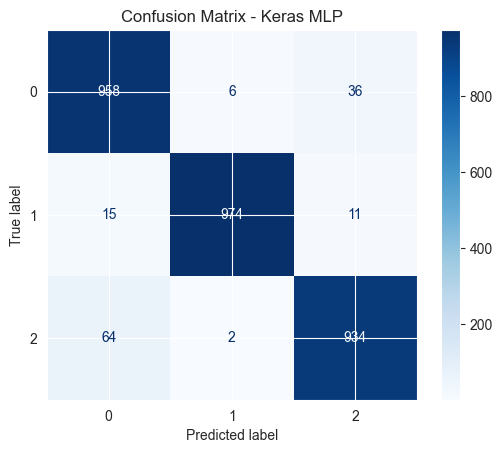

In [10]:
print("\n🤖 Deep Learning (Keras MLP) tuning...")

# Fit preprocessor to training and transform to dense arrays for Keras
prep_only = Pipeline([("pre", preprocessor)])
X_train_pre = prep_only.fit_transform(X_train)
X_test_pre = prep_only.transform(X_test)

input_dim = X_train_pre.shape[1]
if is_binary:
    n_out = 1
    out_activation = "sigmoid"
    loss_name = "binary_crossentropy"
else:
    n_out = num_classes
    out_activation = "softmax"
    loss_name = "sparse_categorical_crossentropy"

def build_mlp(hidden_units=(128, 64), dropout=0.2, lr=1e-3):
    model = keras.Sequential(name="MLP")
    model.add(layers.Input(shape=(input_dim,)))
    for hu in hidden_units:
        model.add(layers.Dense(hu, activation="relu"))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(n_out, activation=out_activation))
    opt = optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss=loss_name, metrics=["accuracy"])
    return model

# Manual hyperparameter search (keep small but meaningful)
mlp_search_space = [
    {"hidden_units": (128, 64), "dropout": 0.2, "lr": 1e-3},
    {"hidden_units": (256, 128), "dropout": 0.3, "lr": 1e-3},
    {"hidden_units": (256, 128, 64), "dropout": 0.3, "lr": 5e-4},
    {"hidden_units": (128,), "dropout": 0.1, "lr": 1e-3},
]

# Split training into train/val for MLP
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pre, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5, restore_best_weights=True
)

mlp_tuning_rows = []
best_val_f1 = -np.inf
best_conf = None
best_model = None

def mlp_predict_labels(model, X):
    """Return class predictions for Keras model, handling binary/multiclass."""
    proba = model.predict(X, verbose=0)
    if is_binary:
        return (proba.ravel() >= 0.5).astype(int), np.vstack([1-proba, proba]).T
    else:
        return np.argmax(proba, axis=1), proba

for conf in mlp_search_space:
    print("Training MLP config:", conf)
    model = build_mlp(conf["hidden_units"], conf["dropout"], conf["lr"])
    hist = model.fit(
        X_tr, y_tr if not is_binary else y_tr.values,
        validation_data=(X_val, y_val if not is_binary else y_val.values),
        epochs=50, batch_size=128, verbose=0, callbacks=[early_stop]
    )
    # Evaluate on validation set using weighted F1
    y_val_pred, y_val_prob = mlp_predict_labels(model, X_val)
    f1_val = f1_score(y_val, y_val_pred, average="weighted")
    acc_val = accuracy_score(y_val, y_val_pred)
    auc_val = compute_auc(y_val, y_val_prob)

    row = {
        "hidden_units": conf["hidden_units"],
        "dropout": conf["dropout"],
        "lr": conf["lr"],
        "val_accuracy": acc_val,
        "val_f1": f1_val,
        "val_auc": auc_val
    }
    mlp_tuning_rows.append(row)
    print("  -> val_acc={:.4f} val_f1={:.4f} val_auc={:.4f}".format(acc_val, f1_val, auc_val))

    if f1_val > best_val_f1:
        best_val_f1 = f1_val
        best_conf = conf
        best_model = model

mlp_tuning_df = pd.DataFrame(mlp_tuning_rows)
print("\n🧪 MLP tuning summary:")
print(mlp_tuning_df.sort_values("val_f1", ascending=False))

# Evaluate best MLP on test set
y_test_pred, y_test_prob = mlp_predict_labels(best_model, X_test_pre)
mlp_acc = accuracy_score(y_test, y_test_pred)
mlp_prec = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
mlp_rec = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
mlp_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)
mlp_auc = compute_auc(y_test, y_test_prob)

print("\n=== Keras MLP (Test) ===")
print("Best config:", best_conf)
print(f"Accuracy={mlp_acc:.4f} | Precision={mlp_prec:.4f} | Recall={mlp_rec:.4f} | F1={mlp_f1:.4f} | AUC={mlp_auc:.4f}")
print(classification_report(y_test, y_test_pred, digits=3))

# Confusion Matrix for MLP
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix - Keras MLP")
plt.show()

# ROC curve for MLP (multi-class OVR numeric above; plotting optional)
try:
    if not is_binary:
        RocCurveDisplay.from_predictions(
            label_binarize(y_test, classes=classes),
            y_test_prob,
            name="MLP (OVR)"
        )
    else:
        RocCurveDisplay.from_predictions(y_test, y_test_prob[:, 1], name="MLP")
    plt.title("ROC Curve - Keras MLP")
    plt.show()
except Exception:
    pass

# Add MLP to comparison table
mlp_row = {"Model": "Keras_MLP", "Accuracy": mlp_acc, "Precision": mlp_prec, "Recall": mlp_rec, "F1": mlp_f1, "AUC": mlp_auc}
test_results_df = pd.concat([test_results_df, pd.DataFrame([mlp_row])], ignore_index=True)


🌀 K-Means clustering on PCA(2) (unsupervised check)
Silhouette: 0.4021 | ARI (vs labels): 0.0332


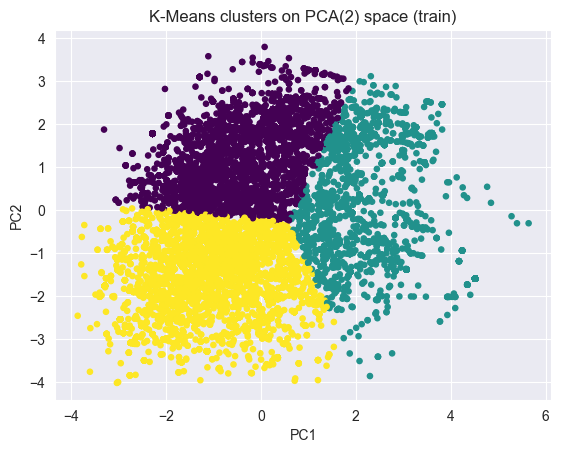

In [11]:
print("\n🌀 K-Means clustering on PCA(2) (unsupervised check)")
X_train_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_train_pre)
k = num_classes if num_classes > 1 else 2
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
kmeans.fit(X_train_2d)
labels = kmeans.labels_
sil = silhouette_score(X_train_2d, labels)
ari = adjusted_rand_score(y_train, labels)
print(f"Silhouette: {sil:.4f} | ARI (vs labels): {ari:.4f}")

plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=labels, s=14, cmap="viridis")
plt.title("K-Means clusters on PCA(2) space (train)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [12]:
cv_results_df.to_csv("cv_results_summary.csv", index=False)
test_results_df.to_csv("test_results_summary.csv", index=False)
lr_compare_df.to_csv("lr_pca_comparison.csv", index=False)
mlp_tuning_df.to_csv("mlp_tuning_summary.csv", index=False)

# Optional: save best MLP weights
try:
    best_model.save("best_mlp.h5")
    print("💾 Saved best MLP weights to best_mlp.h5")
except Exception:
    pass

print("\n💾 Files saved:")
print(" - cv_results_summary.csv")
print(" - test_results_summary.csv")
print(" - lr_pca_comparison.csv")
print(" - mlp_tuning_summary.csv")
print(" - best_mlp.h5 (optional)")
print("\n✅ Complete: classic ML + PCA + K-Means + Keras MLP with tuning & full evaluation")

💾 Saved best MLP weights to best_mlp.h5

💾 Files saved:
 - cv_results_summary.csv
 - test_results_summary.csv
 - lr_pca_comparison.csv
 - mlp_tuning_summary.csv
 - best_mlp.h5 (optional)

✅ Complete: classic ML + PCA + K-Means + Keras MLP with tuning & full evaluation
